# Tax Compliance AutoML: Risk-Based Auditing on Digital Economy

**Authors:** Izam Rosiawan (Data Science) & Sulthan  
**Institution:** Telkom University Surabaya  
**Focus:** Indonesian BPS Digital Economy Indicators & Compliance Risk Management (CRM)
**Methodology:** Automated Machine Learning (Optuna TPE), Anti-Leakage Protocol (`seed=42`), SHAP Explainability

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
import shap

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, 
    f1_score, precision_score, recall_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42
np.random.seed(SEED)
print('Dependencies loaded successfully. Deterministic SEED=42 set.')

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencies loaded successfully. Deterministic SEED=42 set.


## 1. Exploratory Data Analysis & BPS Regional Indicator Ingestion

Dataset menggabungkan indikator makroekonomi BPS (Statistik E-Commerce) dengan parameter mikro transaksi fiskal.

In [2]:
data_path = os.path.join('data', 'bps_e_commerce_tax_compliance.csv')
df = pd.read_csv(data_path)
print(f'Total Dataset Shape: {df.shape}')
display(df.head(5))
print('\nSummary Statistics:')
display(df.describe().T[['mean', 'std', 'min', '50%', 'max']])
print('\nClass Balance:')
print(df['target_compliance_risk'].value_counts(normalize=True))

Total Dataset Shape: (5000, 10)


,provinsi,gmv_transaksi_juta,volume_transaksi_tahunan,proporsi_e_commerce_pct,infrastruktur_digital_score,rasio_pembayaran_digital,frekuensi_pengiriman_logistik,omset_dilaporkan_spt_juta,pajak_disetor_juta,target_compliance_risk
0,DKI Jakarta,17.33,138,38.34,86.48,0.771,150,13.76,0.07,0
1,Sumatera Selatan,406.84,128,37.91,89.52,0.807,110,343.32,1.72,0
2,Riau,429.98,130,42.07,65.00,0.756,142,362.19,1.81,0
3,Banten,48.29,122,29.27,95.18,0.402,120,34.93,0.17,0
4,Banten,77.39,135,49.96,67.34,0.213,139,51.22,0.26,1



Summary Statistics:


,mean,std,min,50%,max
gmv_transaksi_juta,155.690080,145.438915,10.030,112.170,1265.690
volume_transaksi_tahunan,132.093000,10.967334,91.000,132.000,172.000
proporsi_e_commerce_pct,35.460354,11.913297,5.000,35.385,77.680
infrastruktur_digital_score,74.634192,14.119428,50.000,74.520,99.000
rasio_pembayaran_digital,0.713130,0.161403,0.102,0.736,0.999
frekuensi_pengiriman_logistik,124.901800,15.762393,81.000,124.000,181.000
omset_dilaporkan_spt_juta,113.060304,113.239800,4.450,77.855,1153.260
pajak_disetor_juta,0.565300,0.566184,0.020,0.390,5.770
target_compliance_risk,0.250000,0.433056,0.000,0.000,1.000



Class Balance:
target_compliance_risk
0    0.75
1    0.25
Name: proportion, dtype: float64


## 2. Anti-Leakage Data Partitioning & Preprocessing

Pemisahan data latih (80%) dan data uji independen (20%) dilakukan sebelum fitting transformer untuk mencegah *data leakage*.

In [3]:
X = df.drop(columns=['provinsi', 'target_compliance_risk'])
y = df['target_compliance_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training Set: {X_train.shape[0]} observations')
print(f'Holdout Test Set: {X_test.shape[0]} observations')

Training Set: 4000 observations
Holdout Test Set: 1000 observations


## 3. Baseline Models: Logistic Regression & Random Forest

In [4]:
# Logistic Regression Baseline
lr = LogisticRegression(random_state=SEED, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)

print(f'Logistic Regression Test ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}')
print(f'Random Forest Test ROC-AUC:       {roc_auc_score(y_test, rf_probs):.4f}')

Logistic Regression Test ROC-AUC: 0.8677
Random Forest Test ROC-AUC:       0.8719


## 4. AutoML Model Search & Bayesian Hyperparameter Optimization (Optuna TPE)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['LightGBM', 'XGBoost'])
    if classifier_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('lgb_n_estimators', 50, 250),
            'learning_rate': trial.suggest_float('lgb_lr', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('lgb_num_leaves', 15, 127),
            'max_depth': trial.suggest_int('lgb_max_depth', 3, 10),
            'subsample': trial.suggest_float('lgb_subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('lgb_colsample', 0.6, 1.0),
            'random_state': SEED,
            'verbose': -1
        }
        model = lgb.LGBMClassifier(**params)
    else:
        params = {
            'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 250),
            'learning_rate': trial.suggest_float('xgb_lr', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
            'subsample': trial.suggest_float('xgb_subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('xgb_colsample', 0.6, 1.0),
            'random_state': SEED,
            'eval_metric': 'logloss'
        }
        model = xgb.XGBClassifier(**params)
        
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=30)

best_p = study.best_params
print('Optimal Hyperparameters Selected by AutoML:', best_p)

if best_p['classifier'] == 'LightGBM':
    best_automl_model = lgb.LGBMClassifier(
        n_estimators=best_p['lgb_n_estimators'],
        learning_rate=best_p['lgb_lr'],
        num_leaves=best_p['lgb_num_leaves'],
        max_depth=best_p['lgb_max_depth'],
        subsample=best_p['lgb_subsample'],
        colsample_bytree=best_p['lgb_colsample'],
        random_state=SEED,
        verbose=-1
    )
else:
    best_automl_model = xgb.XGBClassifier(
        n_estimators=best_p['xgb_n_estimators'],
        learning_rate=best_p['xgb_lr'],
        max_depth=best_p['xgb_max_depth'],
        subsample=best_p['xgb_subsample'],
        colsample_bytree=best_p['xgb_colsample'],
        random_state=SEED,
        eval_metric='logloss'
    )

best_automl_model.fit(X_train, y_train)
automl_probs = best_automl_model.predict_proba(X_test)[:, 1]
automl_preds = best_automl_model.predict(X_test)
print(f'AutoML Best Test ROC-AUC: {roc_auc_score(y_test, automl_probs):.4f}')

Optimal Hyperparameters Selected by AutoML: {'classifier': 'XGBoost', 'xgb_n_estimators': 177, 'xgb_lr': 0.11277562086831908, 'xgb_max_depth': 3, 'xgb_subsample': 0.9221753053559246, 'xgb_colsample': 0.7623479774444061}
AutoML Best Test ROC-AUC: 0.8978


## 5. Model Explainability (SHAP Values) & Decile Audit Efficiency Analysis

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17856\1675399563.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


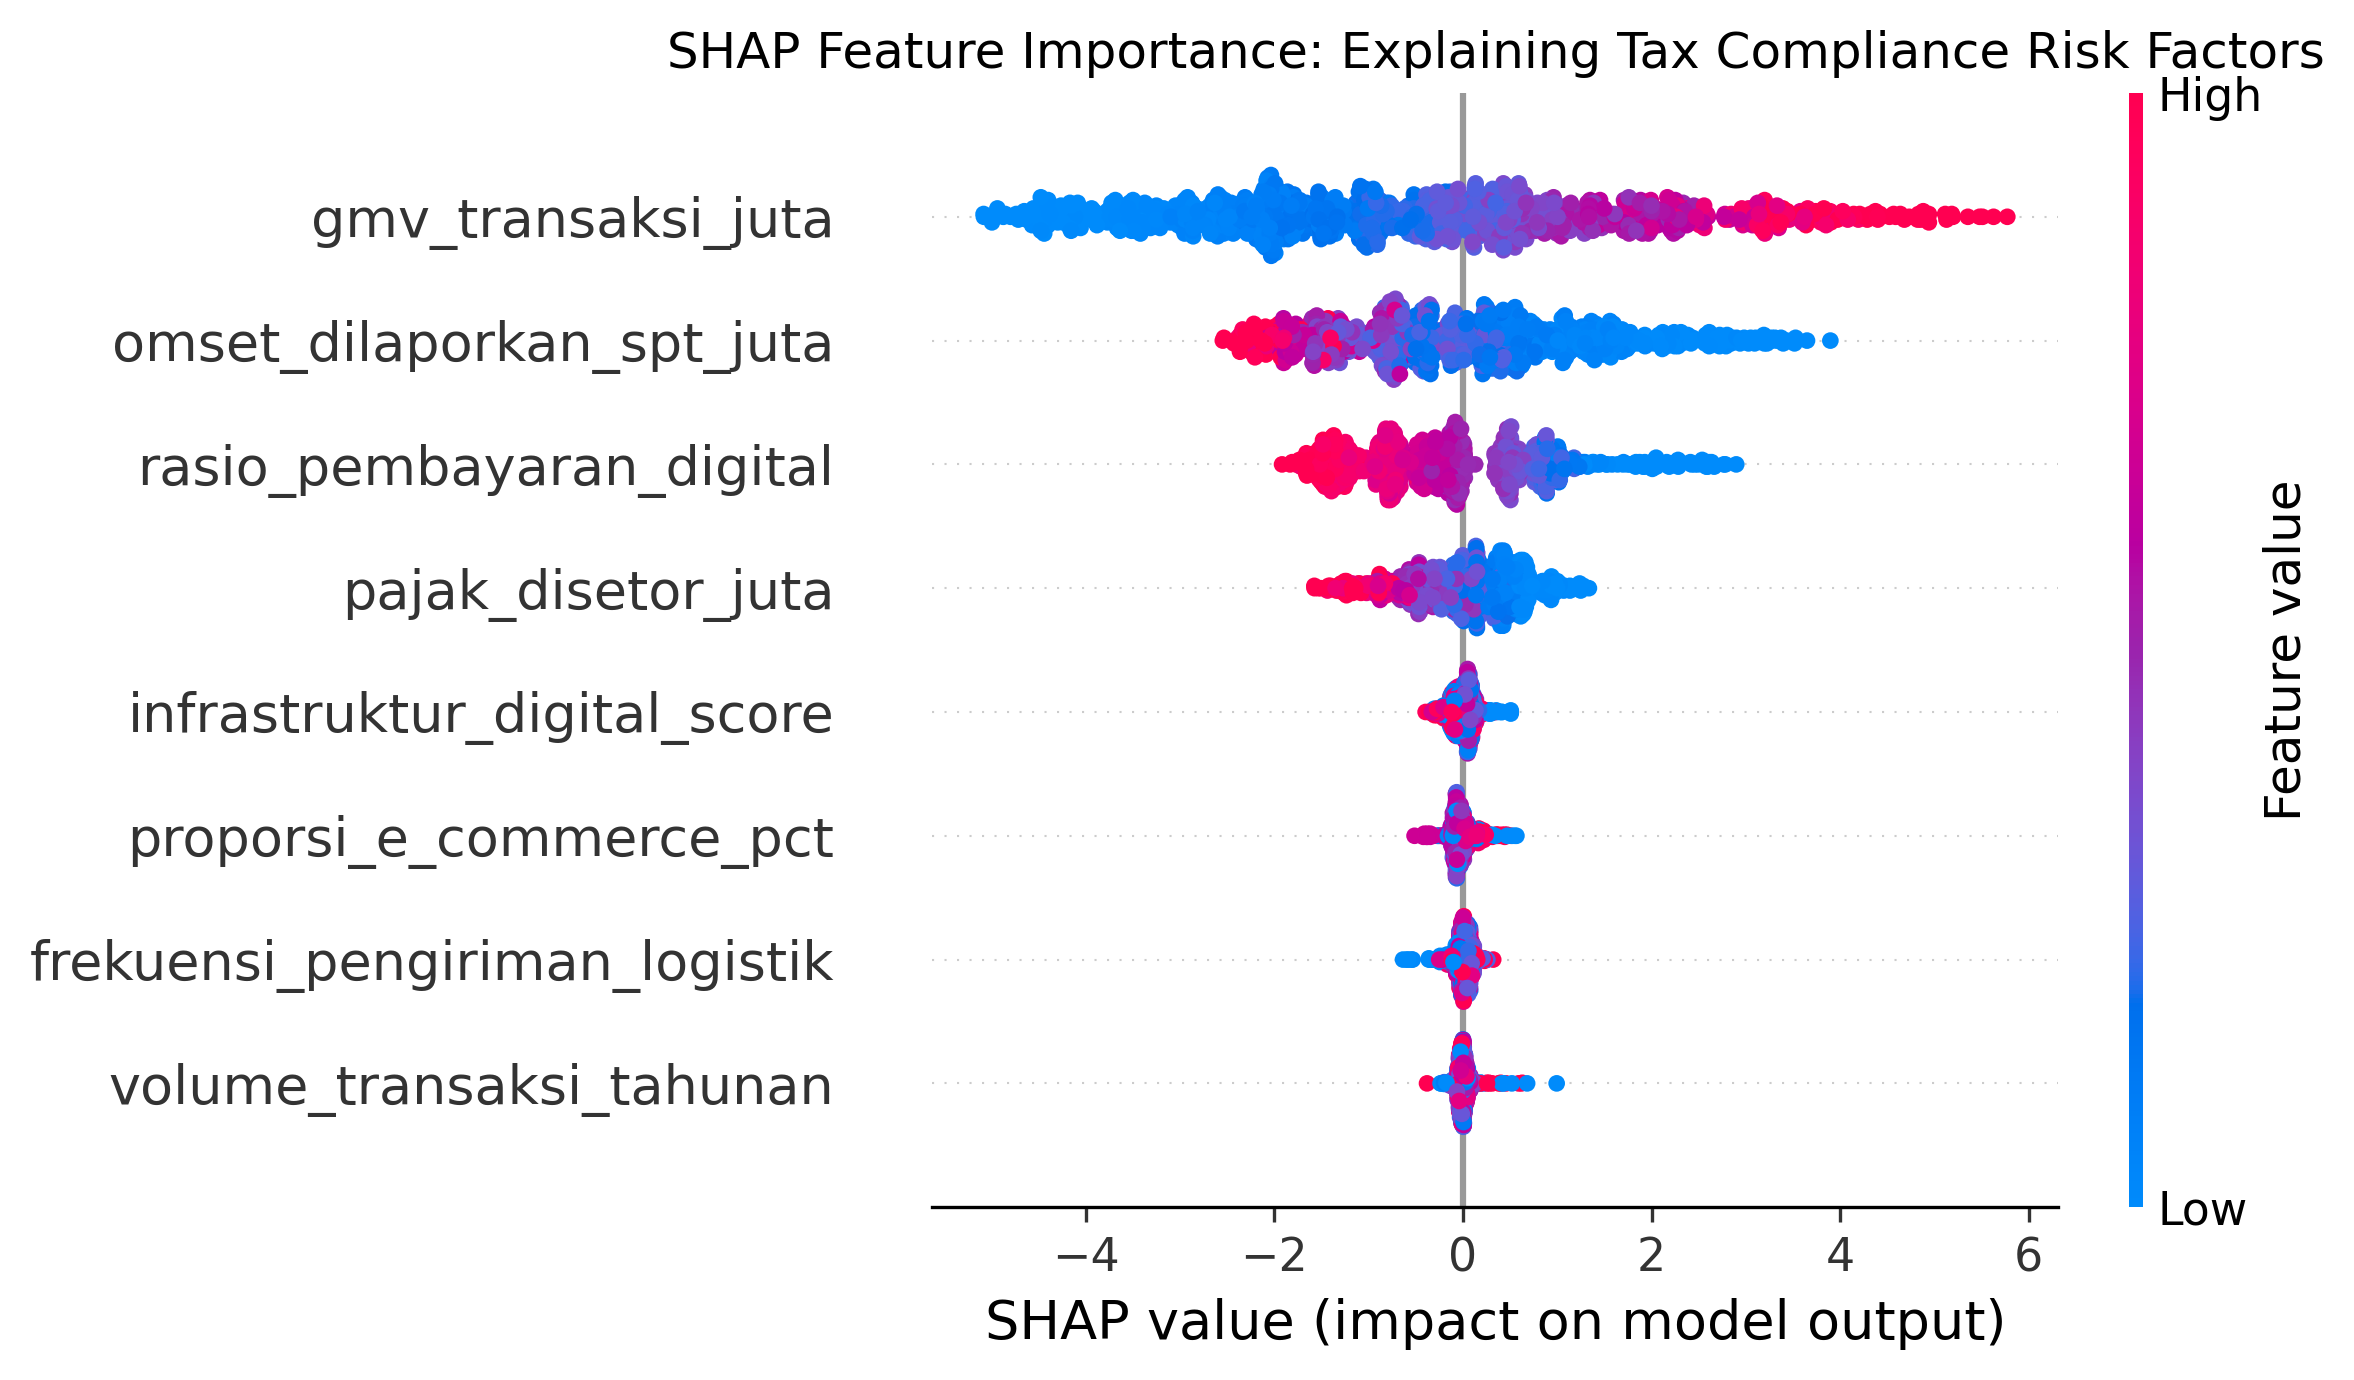

,decile,y_true,cum_gains,cum_gains_pct
0,1,88,88,35.2
1,2,60,148,59.2
2,3,41,189,75.6
3,4,32,221,88.4
4,5,10,231,92.4
5,6,7,238,95.2
6,7,8,246,98.4
7,8,4,250,100.0
8,9,0,250,100.0
9,10,0,250,100.0


Top 20% Risk Deciles capture 59.20% of all high-risk taxpayers.


In [6]:
# SHAP Summary Plot
explainer = shap.TreeExplainer(best_automl_model)
shap_values = explainer(X_test)
plt.figure(figsize=(8, 5), dpi=300)
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance: Explaining Tax Compliance Risk Factors')
plt.tight_layout()
plt.show()

# Cumulative Decile Lift
gains_df = pd.DataFrame({'y_true': y_test, 'prob': automl_probs})
gains_df['decile'] = pd.qcut(gains_df['prob'], q=10, labels=False, duplicates='drop')
gains_df['decile'] = 10 - gains_df['decile']

decile_summary = gains_df.groupby('decile')['y_true'].sum().reset_index()
decile_summary['cum_gains'] = decile_summary['y_true'].cumsum()
decile_summary['cum_gains_pct'] = decile_summary['cum_gains'] / decile_summary['y_true'].sum() * 100.0

display(decile_summary)
print(f'Top 20% Risk Deciles capture {decile_summary.loc[decile_summary["decile"] <= 2, "cum_gains_pct"].max():.2f}% of all high-risk taxpayers.')